Imports

In [1]:
%load_ext autoreload
%autoreload 2

from src.utils.data_io import load_dataset, save_dataset
from src.eda import missing_table, duplicates_summary
from src.preprocessing import (
    clean_data,
    log_transform, skew_comparison, make_hists_after_log,
    scale_data, pca_variance, find_n_components, plot_pca_variance,
)

Import data

In [2]:
df = load_dataset("raw")
df.shape

(8950, 8)

Cleaning

In [3]:
df_clean = clean_data(df)
print(df.shape, "->", df_clean.shape)

(8950, 8) -> (8949, 7)


In [4]:
missing_table(df_clean)

,number,percent
BALANCE,0,0.0
PURCHASES,0,0.0
ONEOFF_PURCHASES,0,0.0
INSTALLMENTS_PURCHASES,0,0.0
CASH_ADVANCE,0,0.0
CREDIT_LIMIT,0,0.0
PAYMENTS,0,0.0


In [5]:
duplicates_summary(df_clean)

{'duplicated_rows': 0}

Log transformation

In [6]:
df_log = log_transform(df_clean.copy())
df_log.head().round(2)

,BALANCE,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS
0,3.74,4.57,0.00,4.57,0.00,6.91,5.31
1,8.07,0.00,0.00,0.00,8.77,8.85,8.32
2,7.82,6.65,6.65,0.00,0.00,8.92,6.43
3,7.42,7.31,7.31,0.00,5.33,8.92,0.00
4,6.71,2.83,2.83,0.00,0.00,7.09,6.52


Skewness before / after

In [7]:
skew_comparison(df_clean, df_log)

,skew_before,skew_after
BALANCE,2.39,-0.86
PURCHASES,8.14,-0.76
ONEOFF_PURCHASES,10.04,0.19
INSTALLMENTS_PURCHASES,7.30,-0.03
CASH_ADVANCE,5.17,0.26
CREDIT_LIMIT,1.52,-0.10
PAYMENTS,5.91,-1.78


Histograms after log

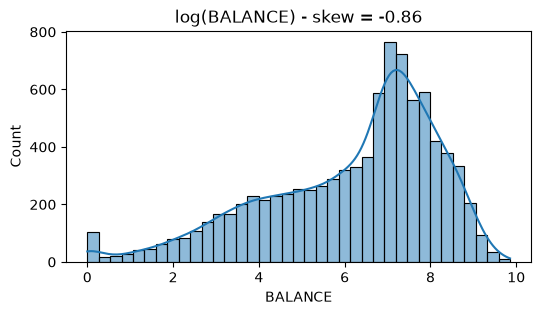

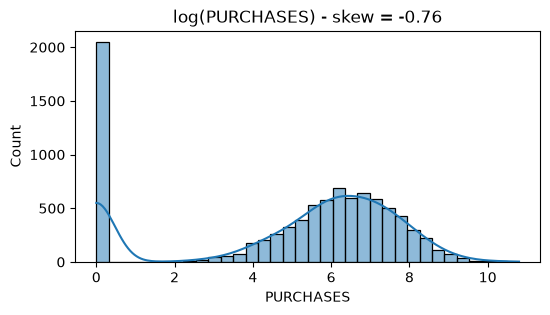

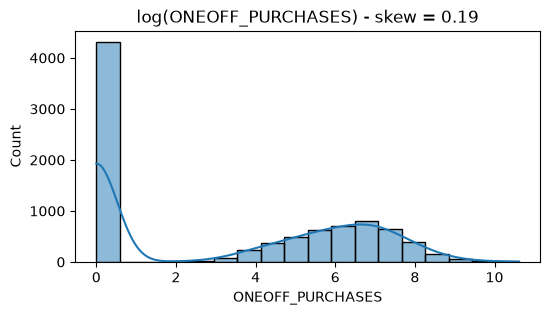

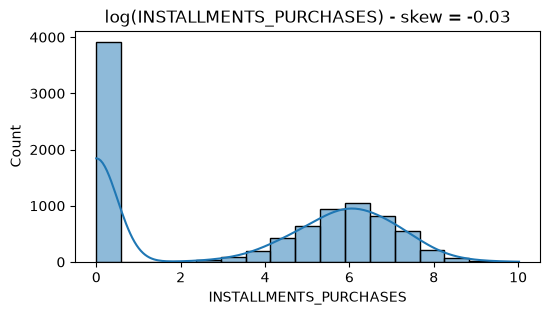

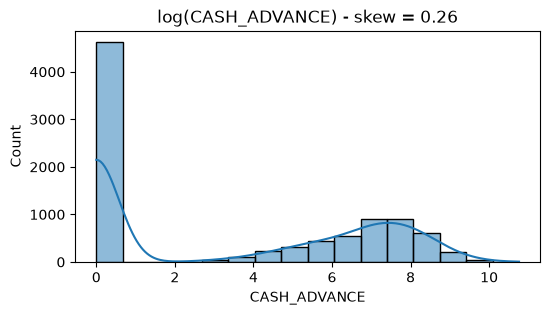

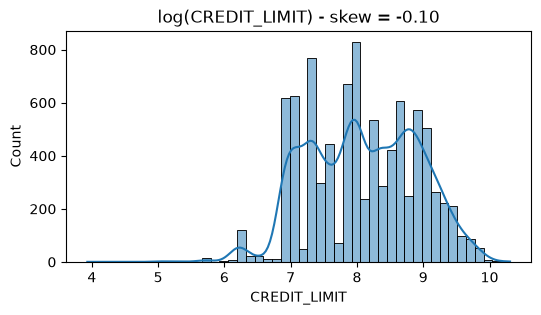

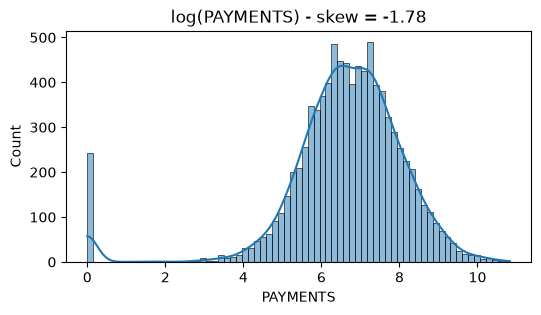

In [8]:
make_hists_after_log(df_log)

Standardization

In [9]:
df_prepare_clustering = scale_data(df_log)
df_prepare_clustering.describe().round(2)

,BALANCE,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS
count,8949.00,8949.00,8949.00,8949.00,8949.00,8949.00,8949.00
mean,0.00,0.00,-0.00,0.00,0.00,0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-3.06,-1.68,-0.99,-1.09,-0.93,-5.08,-4.16
25%,-0.65,-0.41,-0.99,-1.09,-0.93,-0.87,-0.42
50%,0.30,0.34,0.14,0.37,-0.93,-0.11,0.08
75%,0.73,0.72,0.97,0.91,1.04,0.84,0.58
max,1.83,2.02,2.28,2.16,2.09,2.70,2.65


PCA explained variance

In [10]:
pca_table = pca_variance(df_prepare_clustering)
pca_table

,component,variance_explained,variance_cumulative
0,PC1,0.3536,0.3536
1,PC2,0.2926,0.6462
2,PC3,0.1140,0.7602
3,PC4,0.1001,0.8602
4,PC5,0.0763,0.9365
5,PC6,0.0497,0.9862
6,PC7,0.0138,1.0000


Components for 80% variance

In [11]:
n_components = find_n_components(pca_table, threshold=0.8)
n_components

4

PCA cumulative variance curve

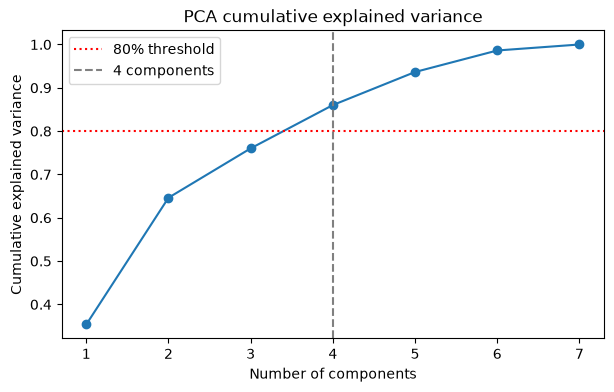

In [12]:
plot_pca_variance(pca_table, threshold=0.8)

Save data

In [13]:
save_dataset(df_clean, "clean")
save_dataset(df_prepare_clustering, "clustering")

Load data